In [4]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os
import contextily as ctx
from glob import glob

from pathlib import Path


# Read XYZ file directly. You can get it at: https://www.swisstopo.admin.ch/en/height-model-swissaltiregio
root_dir = "data/heights"


dfs = []


for csv_path in glob(f"{root_dir}/**/*.xyz/*.xyz", recursive=True):
    # print(f"Reading {csv_path}...")
    df = pd.read_csv(csv_path, sep=' ', header=1, names=['X', 'Y', 'Z'])
    df = df.sample(n=1000, random_state=42)
    dfs.append(df)
    # do something with csv_path


big_df = pd.concat(dfs, ignore_index=True)



print(big_df.head(10))

# Create GeoDataFrame from the points
geometry = [Point(xy) for xy in zip(big_df['X'], big_df['Y'])]
gdf = gpd.GeoDataFrame(big_df, geometry=geometry, crs='EPSG:2056')  # Coordinate system: LV95 (EPSG 2056)

print(f"Loaded {len(gdf)} points")
print(gdf.head())
print(f"Z range: {big_df['Z'].min():.2f} to {big_df['Z'].max():.2f} meters")

           X        Y       Z
0  2677315.0  1244125  525.61
1  2684555.0  1253205  429.69
2  2676315.0  1248325  577.72
3  2683925.0  1248995  517.29
4  2679005.0  1253445  441.23
5  2675505.0  1252645  440.65
6  2684505.0  1247065  437.67
7  2675575.0  1246675  496.32
8  2678345.0  1253485  443.36
9  2678535.0  1244045  546.42
Loaded 31000 points
           X        Y       Z                 geometry
0  2677315.0  1244125  525.61  POINT (2677315 1244125)
1  2684555.0  1253205  429.69  POINT (2684555 1253205)
2  2676315.0  1248325  577.72  POINT (2676315 1248325)
3  2683925.0  1248995  517.29  POINT (2683925 1248995)
4  2679005.0  1253445  441.23  POINT (2679005 1253445)
Z range: 320.43 to 1527.01 meters


In [6]:
# reduce number of points for plotting to a random sample of 10000
gdf = gdf.sample(n=1000, random_state=42)

In [7]:

# gdf['color'] = gdf['purpose'].apply(lambda x: 'grey' if x == 'outside' else 'blue')


# Assign a color proportional to elevation
gdf['color'] = gdf['Z']
# .apply(lambda z: (z - gdf['Z'].min()) / (gdf['Z'].max() - gdf['Z'].min()))

print("Added color based on elevation")

# ax = gdf.plot(
#     figsize=(15,15),
#     legend=True,
#     c=gdf['color']
# )

# ctx.add_basemap(ax=ax, crs=gdf.crs)

print("Plotted points with basemap")

gdf = gdf.drop(columns=['color', 'X', 'Y'], axis=1)

Added color based on elevation
Plotted points with basemap


In [8]:
import matsim

network = matsim.read_network("scenarios/Zurich_10pct/zurich_10pct_network.xml")
print(network)

Network: 55214 nodes, 122687 links, Atlantis


       node_id                         geometry
0   1000138721   POINT (2689122.07 1281700.625)
1  10001518780  POINT (2672602.677 1250951.352)
2    100016591  POINT (2680227.888 1254504.487)
3    100017223  POINT (2679129.241 1254770.953)
4    100018715  POINT (2678533.155 1254806.624)
5    100018718  POINT (2678501.564 1254958.819)
6    100018989  POINT (2678401.262 1254425.627)
7   1000193915  POINT (2689660.867 1281128.813)
8   1000198181  POINT (2690176.857 1280750.867)
9   1000204287  POINT (2690218.997 1280644.798)
55214


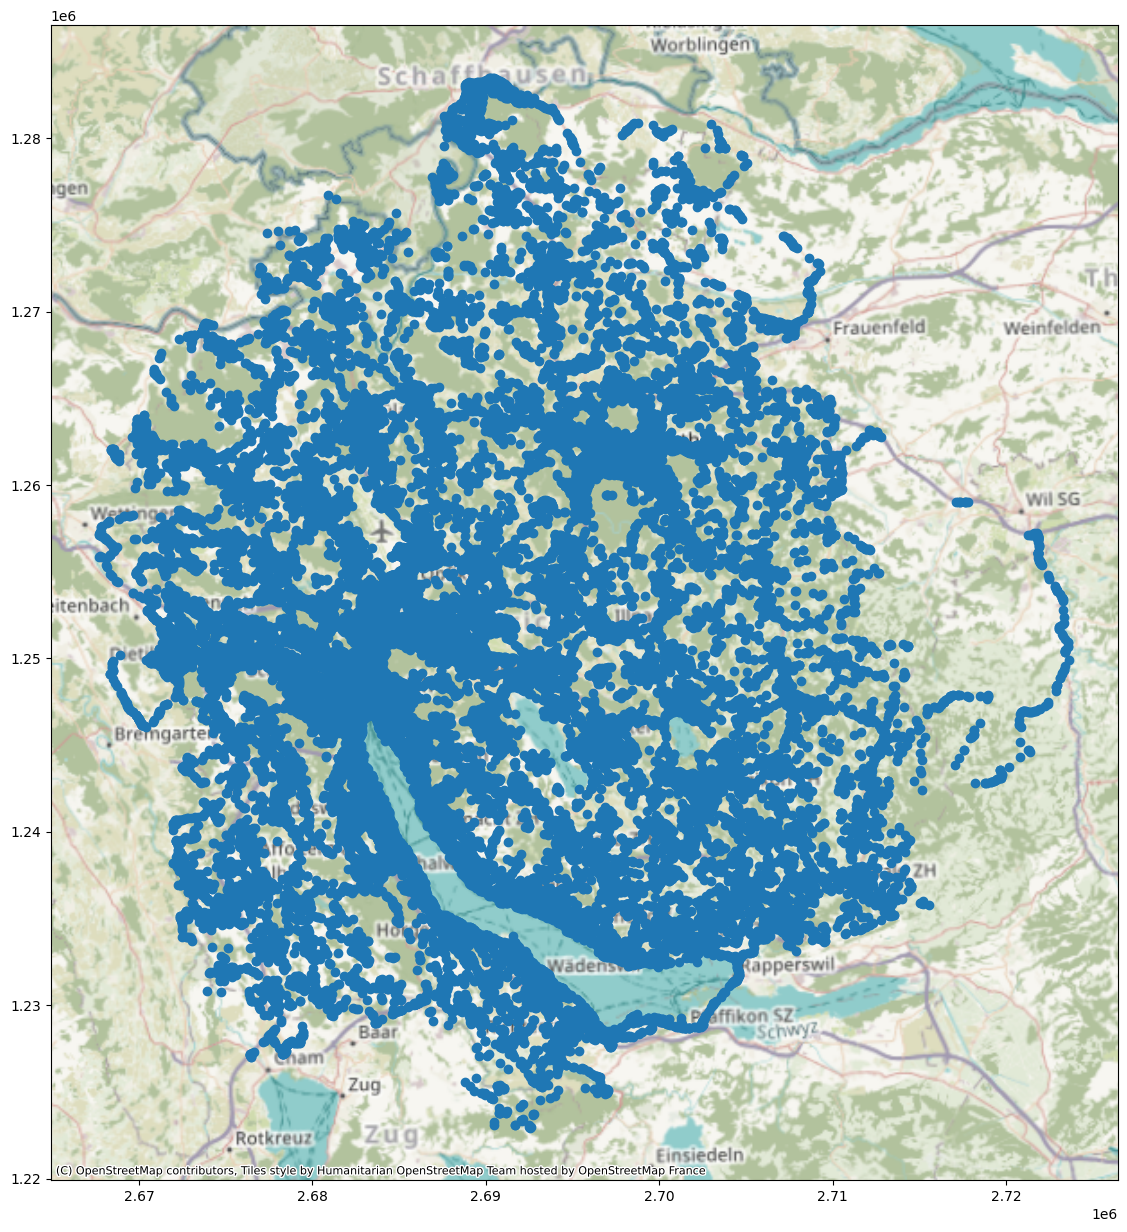

In [9]:
# print(network.nodes)
# Turn nodes into a GeoDataFrame
nodes_gdf = gpd.GeoDataFrame(
    network.nodes[['node_id']],
    geometry=[Point(x, y) for x, y in zip(network.nodes.x, network.nodes.y)],
    crs=gdf.crs
)

ax = nodes_gdf.plot(
    figsize=(15,15),
    legend=True,
)


ctx.add_basemap(ax=ax, crs=gdf.crs)

print(nodes_gdf.head(10))
print(len(nodes_gdf))

In [10]:

result = gpd.sjoin_nearest(nodes_gdf, gdf, how='left', distance_col='dist_m')
    
result = result.drop(columns=['index_right'], axis=1)

print(result.head(10))
# print length
print(len(result))

       node_id                         geometry       Z       dist_m
0   1000138721   POINT (2689122.07 1281700.625)  473.40   546.618295
1  10001518780  POINT (2672602.677 1250951.352)  385.40  1510.737637
2    100016591  POINT (2680227.888 1254504.487)  498.29  1107.829907
3    100017223  POINT (2679129.241 1254770.953)  440.24   707.655073
4    100018715  POINT (2678533.155 1254806.624)  440.24   219.238505
5    100018718  POINT (2678501.564 1254958.819)  440.24    67.031439
6    100018989  POINT (2678401.262 1254425.627)  440.24   592.809852
7   1000193915  POINT (2689660.867 1281128.813)  473.40   506.543866
8   1000198181  POINT (2690176.857 1280750.867)  473.40  1098.869940
9   1000204287  POINT (2690218.997 1280644.798)  473.40  1179.998394
55214


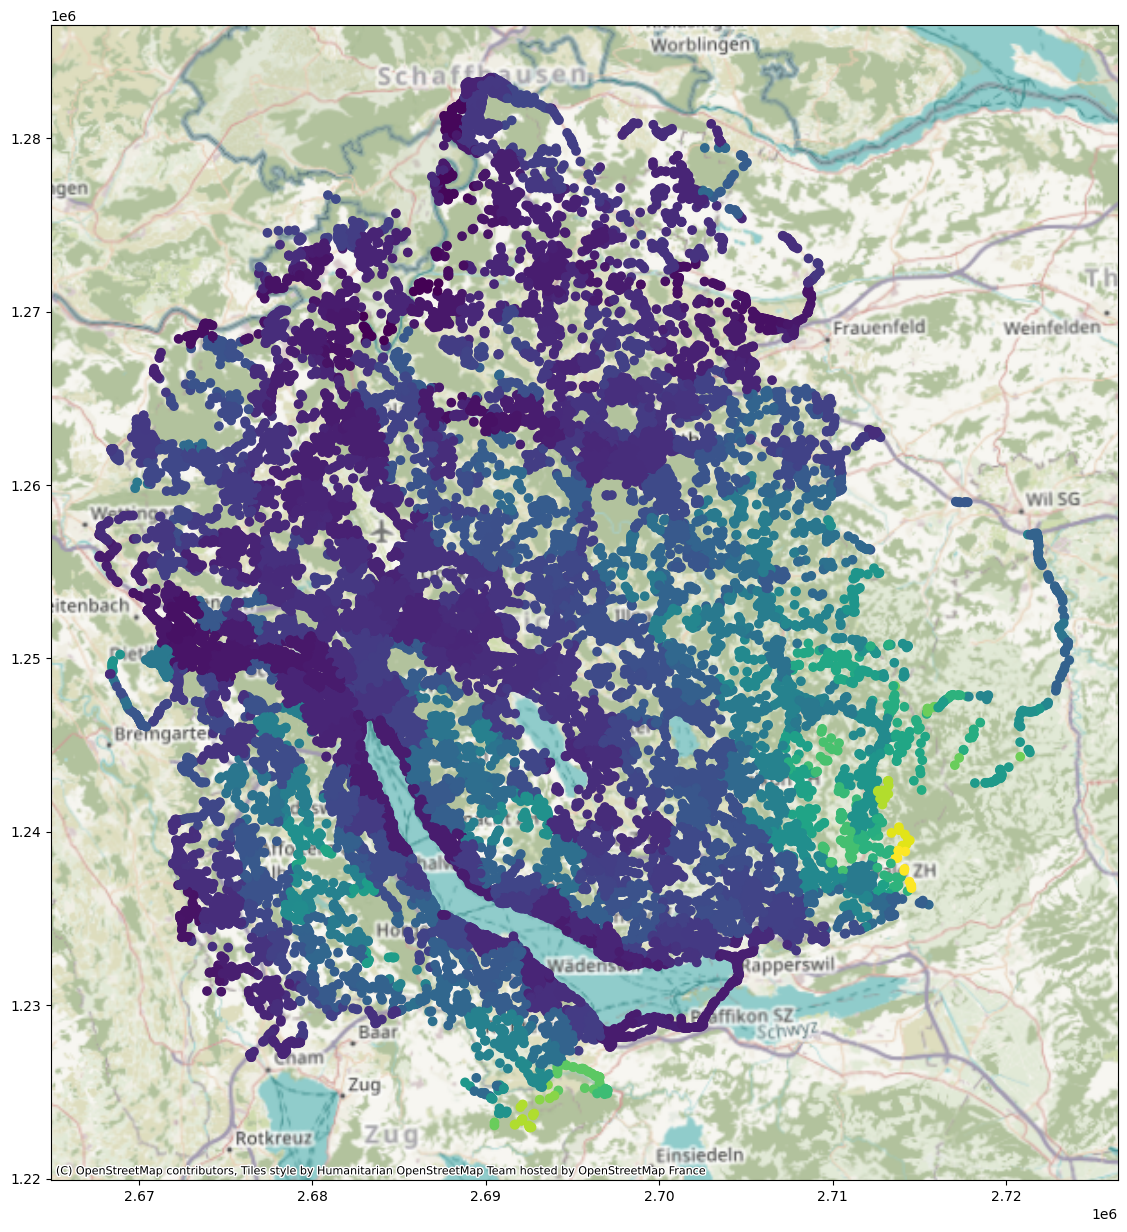

In [11]:
ax = result.plot(
    figsize=(15,15),
    legend=True,
    c=result['Z']
)

ctx.add_basemap(ax=ax, crs=gdf.crs)

In [12]:
# Save the result to a CSV file
output_path = Path("data/heights/nodes_with_elevation.csv")
result.to_csv(output_path, index=False)
print(f"Saved result to {output_path}")

Saved result to data/heights/nodes_with_elevation.csv


In [13]:
geo_network = network.as_geo(gdf.crs)
print(geo_network.head(10))

       length  freespeed  capacity  permlanes oneway  \
0   10.319129   8.333333     600.0        1.0      1   
1  175.991341  13.888889     600.0        1.0      1   
2  175.991341  13.888889     600.0        1.0      1   
3  135.937426  13.888889     600.0        1.0      1   
4  135.937426  13.888889     600.0        1.0      1   
5   14.280440  13.888889     600.0        1.0      1   
6   14.280440  13.888889     600.0        1.0      1   
7  262.068856  13.888889     600.0        1.0      1   
8  262.068856  13.888889     600.0        1.0      1   
9   24.226971   8.333333     600.0        1.0      1   

                                 modes  link_id   from_node     to_node  \
0  bus,car,car_passenger,pt,taxi,truck    10000    34181019  1731940564   
1  bus,car,car_passenger,pt,taxi,truck  1000021   408785000   408784999   
2  bus,car,car_passenger,pt,taxi,truck  1000022   408784999   408785000   
3  bus,car,car_passenger,pt,taxi,truck  1000023   408784999  1841788180   
4  bus,c

/home/leopold/Documents/repos/abmt2025-repos/eqasim-java/.venv/lib/python3.13/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


In [14]:
network_with_height = matsim.read_network("scenarios/Zurich_10pct/zurich_10pct_network_z.xml")

print(network_with_height)

nodes_gdf = gpd.GeoDataFrame(
    network_with_height.nodes[['node_id']],
    geometry=[Point(x, y) for x, y in zip(network.nodes.x, network.nodes.y)],
    crs=gdf.crs
)

print(nodes_gdf.head(10))

Network: 55214 nodes, 122687 links, Atlantis
       node_id                         geometry
0   1000138721   POINT (2689122.07 1281700.625)
1  10001518780  POINT (2672602.677 1250951.352)
2    100016591  POINT (2680227.888 1254504.487)
3    100017223  POINT (2679129.241 1254770.953)
4    100018715  POINT (2678533.155 1254806.624)
5    100018718  POINT (2678501.564 1254958.819)
6    100018989  POINT (2678401.262 1254425.627)
7   1000193915  POINT (2689660.867 1281128.813)
8   1000198181  POINT (2690176.857 1280750.867)
9   1000204287  POINT (2690218.997 1280644.798)
